In [ ]:
!pip install numpy


  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)


In [107]:
# from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



In [108]:
links = pd.read_csv('links.csv')
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
tags = pd.read_csv('tags.csv')

In [109]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [110]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [111]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [112]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [113]:
tags.shape


(3683, 4)

In [114]:
movies.shape


(9742, 3)

In [115]:
links.shape


(9742, 3)

In [116]:
ratings.shape

(100836, 4)

In [117]:
ratings


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [118]:
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'],unit ='s')

In [119]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [120]:
ratings = ratings.sort_values(['userId', 'timestamp'])
test = ratings.groupby('userId').tail(1)
train = ratings.drop(test.index)

In [121]:
train.shape

(100226, 4)

In [122]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,100836
mean,326.127564,19435.295718,3.501557,2008-03-19 17:01:27.368469504
min,1.000000,1.000000,0.500000,1996-03-29 18:36:55
25%,177.000000,1199.000000,3.000000,2002-04-18 09:57:46
50%,325.000000,2991.000000,3.500000,2007-08-02 20:31:02
75%,477.000000,8122.000000,4.000000,2015-07-04 07:15:44.500000
max,610.000000,193609.000000,5.000000,2018-09-24 14:27:30
std,182.618491,35530.987199,1.042529,NaN


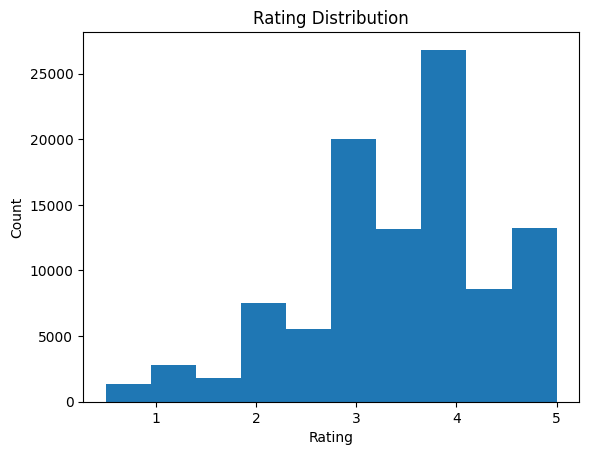

In [123]:
plt.hist(ratings['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

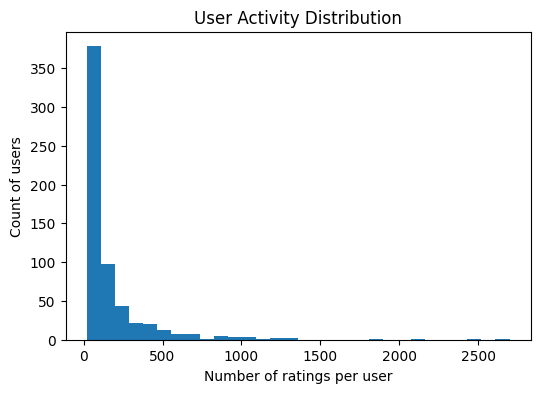

In [124]:
# Ratings per user
user_activity = ratings.groupby('userId').size()

plt.figure(figsize=(6,4))
plt.hist(user_activity, bins=30)
plt.title("User Activity Distribution")
plt.xlabel("Number of ratings per user")
plt.ylabel("Count of users")
plt.show()


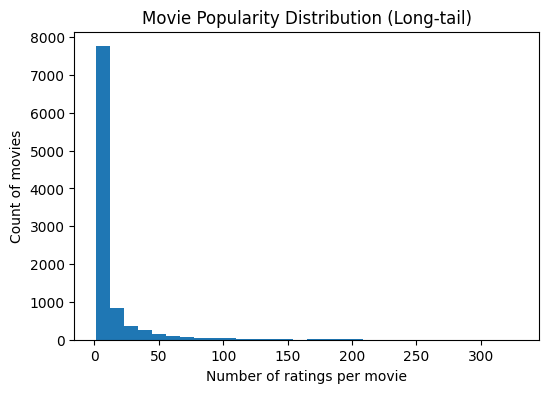

In [125]:
# Ratings per movie
movie_popularity = ratings.groupby('movieId').size()

plt.figure(figsize=(6,4))
plt.hist(movie_popularity, bins=30)
plt.title("Movie Popularity Distribution (Long-tail)")
plt.xlabel("Number of ratings per movie")
plt.ylabel("Count of movies")
plt.show()


In [126]:
print(movies.columns)
print(movies['genres'].head())


Index(['movieId', 'title', 'genres'], dtype='object')
0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
Name: genres, dtype: object


Top genres:
genres
Drama             1053
Comedy             946
Comedy|Drama       435
Comedy|Romance     363
Drama|Romance      349
Name: count, dtype: int64


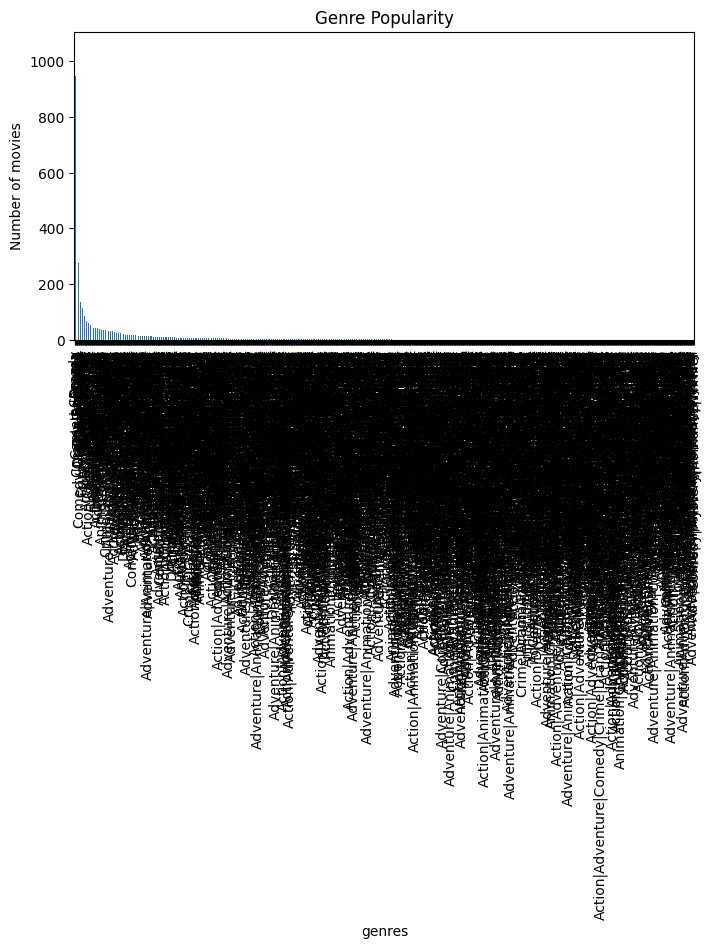

In [127]:
# Genre popularity plot (correct for list-type genres)

genre_df = movies.copy()

# Remove rows where genres are empty
genre_df = genre_df[genre_df['genres'].notna()]

# Explode list of genres
genre_exploded = genre_df.explode('genres')

# Count genres
genre_counts = genre_exploded['genres'].value_counts()

print("Top genres:")
print(genre_counts.head())

# Plot
plt.figure(figsize=(8,4))
genre_counts.plot(kind='bar')
plt.title("Genre Popularity")
plt.ylabel("Number of movies")
plt.show()


In [128]:
# ==============================
# Popularity-based recommender
# ==============================

popular_movies = (
    train.groupby('movieId')
    .size()
    .sort_values(ascending=False)
)

def popularity_recommend(k=10):
    return popular_movies.head(k).index.tolist()

print("Top-10 popular movies:", popularity_recommend())


Top-10 popular movies: [356, 318, 296, 2571, 593, 260, 110, 480, 589, 2959]


In [129]:
user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_map = {u:i for i,u in enumerate(user_ids)}
movie_map = {m:i for i,m in enumerate(movie_ids)}

n_users = len(user_ids)
n_movies = len(movie_ids)

In [130]:
k = 20 #latent dimenstion
lr = 0.01
reg = 0.02
epochs = 30

P = np.random.normal(scale = 1/k , size = (n_users,k))
Q = np.random.normal(scale = 1/k , size = (n_movies,k))

In [131]:
for epoch in range(epochs):
  for row in train.itertuples():
    u = user_map[row.userId]
    m = movie_map[row.movieId]
    r = row.rating

    pred = np.dot(P[u], Q[m])
    err = r - pred

    P[u] += lr*(err*Q[m] - reg*P[u])
    Q[m] += lr*(err*P[u] - reg*Q[m])

print(f"Epoch {epoch+1} Completed .")

Epoch 30 Completed .


In [73]:
# print("NaN in P:", np.isnan(P).any())
# print("NaN in Q:", np.isnan(Q).any())


In [132]:
errors = []

for row in test.itertuples():
    # skip invalid ratings
    if pd.isna(row.rating):
        continue

    if row.userId in user_map and row.movieId in movie_map:
        u = user_map[row.userId]
        m = movie_map[row.movieId]
        pred = np.dot(P[u], Q[m])
    else:
        pred = train['rating'].mean()  # cold start fallback

    errors.append((row.rating - pred) ** 2)

errors = np.array(errors, dtype=float)

print("Valid samples used:", len(errors))
print("Any NaN left:", np.isnan(errors).any())

rmse = np.sqrt(errors.mean())
print("RMSE:", rmse)


Valid samples used: 610
Any NaN left: False
RMSE: 0.9805258131278531


In [75]:
# nan_rating_count = 0

# for row in test.itertuples():
#     if pd.isna(row.rating):
#         nan_rating_count += 1

# print("NaN ratings in test set:", nan_rating_count)



In [133]:
movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))

mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(movies['genres'])

tag_text = tags.groupby('movieId')['tag'] \
               .apply(lambda x: ' '.join(x)) \
               .reset_index()

movies = movies.merge(tag_text, on='movieId', how='left')
movies['tag'] = movies['tag'].fillna("")

tfidf = TfidfVectorizer(max_features=500)
tag_features = tfidf.fit_transform(movies['tag'])

content_features = np.hstack([genre_features, tag_features.toarray()])
content_similarity = cosine_similarity(content_features)



In [134]:
movie_index_map = {m: i for i, m in enumerate(movies.movieId)}

all_movies = movies['movieId'].unique()

def hybrid_recommend(user_id, top_k=10, alpha=0.7):
    if user_id not in user_map:
        return []

    scores = []
    u = user_map[user_id]

    seen = set(train[train.userId == user_id].movieId)

    liked_movies = train[
        (train.userId == user_id) & (train.rating >= 4)
    ].movieId.tolist()

    liked_idx = [
        movie_index_map[m] for m in liked_movies
        if m in movie_index_map
    ]

    for movie_id in all_movies:
        if movie_id not in movie_map:
            continue
        if movie_id in seen:
            continue

        m = movie_map[movie_id]

        # CF score
        cf_score = np.dot(P[u], Q[m])

        # Content score
        content_score = 0
        if liked_idx and movie_id in movie_index_map:
            i2 = movie_index_map[movie_id]
            sims = content_similarity[liked_idx, i2]
            content_score = np.mean(sims)

        final_score = alpha * cf_score + (1 - alpha) * content_score
        scores.append((movie_id, final_score))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]



In [135]:
def ranking_metrics(user_id, k=10):
    # Relevant items = movies user liked in test set
    relevant = set(
        test[(test.userId == user_id) & (test.rating >= 4)].movieId
    )

    if len(relevant) == 0:
        return 0, 0, 0

    recs = hybrid_recommend(user_id, k)
    recommended_ids = [m for m, _ in recs]

    hits = [1 if m in relevant else 0 for m in recommended_ids]

    precision = sum(hits) / k
    recall = sum(hits) / len(relevant)

    dcg = sum(hit / np.log2(i + 2) for i, hit in enumerate(hits))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    ndcg = dcg / idcg if idcg > 0 else 0

    return precision, recall, ndcg


In [142]:
def explain_recommendation(user_id, movie_id):
    liked = train[(train.userId == user_id) & (train.rating >= 4)]
    target_row = movies[movies.movieId == movie_id]

    if len(target_row) == 0:
        return "Recommended based on similar users."

    target = target_row.iloc[0]
    target_genres = set(target.genres)

    for _, row in liked.iterrows():
        liked_movie = movies[movies.movieId == row.movieId]

        if len(liked_movie) == 0:
            continue

        liked_movie = liked_movie.iloc[0]
        liked_genres = set(liked_movie.genres)

        common = liked_genres.intersection(target_genres)

        if common:
            return (
                f"Because you liked '{liked_movie.title}', "
                f"which shares genres {list(common)}"
            )

    return "Recommended based on similar users and content."


In [137]:
def intra_list_diversity(movie_ids):
    idx = []
    for m in movie_ids:
        rows = movies[movies.movieId == m]
        if len(rows) > 0:
            idx.append(rows.index[0])

    if len(idx) < 2:
        return 0

    sims = content_similarity[np.ix_(idx, idx)]
    return 1 - np.mean(sims)
# Movie popularity
movie_pop = train.groupby('movieId').size()
total_ratings = movie_pop.sum()

def novelty(recs):
    scores = []
    for m in recs:
        pop = movie_pop.get(m, 1)
        scores.append(-np.log2(pop / total_ratings))
    return np.mean(scores)


def catalog_coverage_all_users(k=10):
    all_recs = set()
    for u in test.userId.unique():
        recs = hybrid_recommend(u, k)
        all_recs.update(recs)

    return len(all_recs) / movies.movieId.nunique()

print("Catalog Coverage:", catalog_coverage_all_users(10))



Catalog Coverage: 0.6261547936768631


In [138]:
print("Novelty@10:", novelty(recs))


Novelty@10: 16.61289728641633


In [139]:
def evaluate_all_users(k=10, max_users=100):
    precisions, recalls, ndcgs = [], [], []

    users = test.userId.unique()[:max_users]

    for user_id in users:
        p, r, n = ranking_metrics(user_id, k)

        if p == r == n == 0:
            continue

        precisions.append(p)
        recalls.append(r)
        ndcgs.append(n)

    return (
        np.mean(precisions),
        np.mean(recalls),
        np.mean(ndcgs)
    )
# ==============================
# MAP@K metric
# ==============================

def apk(actual, predicted, k=10):
    score = 0.0
    hits = 0.0

    for i, p in enumerate(predicted[:k]):
        if p in actual and p not in predicted[:i]:
            hits += 1
            score += hits / (i + 1)

    if len(actual) == 0:
        return 0.0

    return score / min(len(actual), k)


def mapk(test, k=10):
    scores = []
    for u in test.userId.unique():
        actual = test[test.userId == u].movieId.tolist()
        pred = hybrid_recommend(u, k)
        scores.append(apk(actual, pred, k))
    return np.mean(scores)


p_avg, r_avg, n_avg = evaluate_all_users(10)

print("Average Precision@10:", p_avg)
print("Average Recall@10:", r_avg)
print("Average NDCG@10:", n_avg)
print("MAP@10:", mapk(test, 10))



Average Precision@10: 0.1
Average Recall@10: 1.0
Average NDCG@10: 0.3010299956639812
MAP@10: 0.0


In [145]:
user = 30
recs = hybrid_recommend(user)

movie_list = []

for m, s in recs:
    title = movies[movies.movieId == m]['title'].values[0]
    print(title)
    print(explain_recommendation(user, m))
    print("-"*40)
    movie_list.append(m)

print("Diversity:", intra_list_diversity(movie_list))
print("Coverage:", catalog_coverage_all_users(10))


Submarine (2010)
Because you liked 'Shawshank Redemption, The (1994)', which shares genres ['Drama']
----------------------------------------
Never Cry Wolf (1983)
Because you liked 'Star Wars: Episode IV - A New Hope (1977)', which shares genres ['Adventure']
----------------------------------------
Reign Over Me (2007)
Because you liked 'Shawshank Redemption, The (1994)', which shares genres ['Drama']
----------------------------------------
Day of the Doctor, The (2013)
Because you liked 'Star Wars: Episode IV - A New Hope (1977)', which shares genres ['Adventure', 'Sci-Fi']
----------------------------------------
Gladiator (1992)
Because you liked 'Star Wars: Episode IV - A New Hope (1977)', which shares genres ['Action']
----------------------------------------
Autumn Sonata (Höstsonaten) (1978)
Because you liked 'Shawshank Redemption, The (1994)', which shares genres ['Drama']
----------------------------------------
Raiders of the Lost Ark: The Adaptation (1989)
Because you lik